## BUCKET 1 MODEL

In [7]:
## EXTRA TREES REGRESSION FOR BUCKET 0 ONLY
## Bucket 0 = short dwell: 0-72 hours

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load data
df = pd.read_csv("../data_final/eurogate_postdeparture.csv")

TARGET = "dwell_hours"

# Create same 3 dwell-time buckets as classifier
df["dwell_bucket_3"] = pd.cut(
    df[TARGET],
    bins=[0, 72, 240, np.inf],
    labels=[0, 1, 2],
    include_lowest=True
).astype(int)

# Keep only bucket 1 rows
df = df[df["dwell_bucket_3"] == 0].copy()

print(f"Bucket 0 rows: {len(df):,}")

# Lightweight engineered features
df["gross_per_teu"] = df["gross"] / df["teu"].replace(0, np.nan)

df["vessel_workload"] = (
    df["numberOfArrivalContainersOnVessel"]
    + df["numberOfDepartureContainersOnVessel"]
)

df["vessel_total_count"] = (
    df["numberOfArrivalContainersOnVessel"]
    + df["numberOfRemainOnBoardContainersOnVessel"]
    + df["numberOfDepartureContainersOnVessel"]
)

df["vessel_discharge_ratio"] = (
    df["numberOfArrivalContainersOnVessel"]
    / df["vessel_total_count"].replace(0, np.nan)
)

df["vessel_departure_ratio"] = (
    df["numberOfDepartureContainersOnVessel"]
    / df["vessel_total_count"].replace(0, np.nan)
)

df["wind_rain_interaction"] = df["wind_speed_10m"] * df["precipitation"]
df["humidity_temp_interaction"] = df["relative_humidity_2m"] * df["temperature_2m"]

# Drop leakage / non-model columns
drop_cols = [
    "dwell_hours",
    "dwell_bucket",
    "dwell_bucket_3",
    "snapshot_time",
    "snapshot_date",
    "snapshot_year",
    "snapshot_hour",
    "snapshot_minute",
    "snapshot_second",
    "arrival_year",
    "departureTime",
    "remaining_dwell_hours",
    "elapsed_dwell_hours",
    "Unnamed: 0",
    "Unnamed: 0.1",
    "Unnamed: 0.2",
    "containerId"
]

df = df.dropna(subset=[TARGET]).copy()

X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df[TARGET]

# Clean features
X = X.replace([np.inf, -np.inf], np.nan)

object_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Dropping object columns:", object_cols)
X = X.drop(columns=object_cols)

bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

X = X.fillna(X.median(numeric_only=True))

# Log target
y_log = np.log1p(y)

# Train/test split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=42
)

y_test = np.expm1(y_test_log)

# Baseline
baseline = DummyRegressor(strategy="median")
baseline.fit(X_train, y_train_log)

baseline_pred_log = baseline.predict(X_test)
baseline_pred = np.maximum(np.expm1(baseline_pred_log), 0)

print("\nBaseline Median — Bucket 0")
print("--------------------------")
print(f"MAE: {mean_absolute_error(y_test, baseline_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):.2f}")
print(f"R²: {r2_score(y_test, baseline_pred):.4f}")

# Extra Trees Regressor
model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=40,
    min_samples_leaf=1,
    min_samples_split=5,
    max_features=0.75,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train_log)

pred_log = model.predict(X_test)
pred = np.maximum(np.expm1(pred_log), 0)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

within_6 = (np.abs(y_test - pred) <= 6).mean()
within_12 = (np.abs(y_test - pred) <= 12).mean()
within_24 = (np.abs(y_test - pred) <= 24).mean()

print("\nExtra Trees Regression — Bucket 0")
print("---------------------------------")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")
print(f"Within 6h: {within_6:.2%}")
print(f"Within 12h: {within_12:.2%}")
print(f"Within 24h: {within_24:.2%}")

# Save predictions
predictions = pd.DataFrame({
    "actual_dwell_hours": y_test,
    "predicted_dwell_hours": pred,
    "error_hours": pred - y_test
})

predictions.to_csv(
    "../feature_importance/bucket0_extra_trees_regression_predictions.csv",
    index=False
)

# Save feature importance
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance.to_csv(
    "../feature_importance/bucket0_extra_trees_regression_feature_importance.csv",
    index=False
)

# Save model
joblib.dump(
    model,
    "../feature_importance/bucket0_extra_trees_regression_model.joblib"
)

print("\nSaved:")
print("../feature_importance/bucket0_extra_trees_regression_predictions.csv")
print("../feature_importance/bucket0_extra_trees_regression_feature_importance.csv")
print("../feature_importance/bucket0_extra_trees_regression_model.joblib")

Bucket 0 rows: 65,622
Dropping object columns: []

Baseline Median — Bucket 0
--------------------------
MAE: 15.51
RMSE: 18.25
R²: -0.0008

Extra Trees Regression — Bucket 0
---------------------------------
MAE: 8.43
RMSE: 12.79
R²: 0.5082
Within 6h: 56.27%
Within 12h: 74.88%
Within 24h: 91.26%

Saved:
../feature_importance/bucket0_extra_trees_regression_predictions.csv
../feature_importance/bucket0_extra_trees_regression_feature_importance.csv
../feature_importance/bucket0_extra_trees_regression_model.joblib


## BUCKET 2 MODEL

In [8]:
## EXTRA TREES REGRESSION FOR BUCKET 1 ONLY
## Bucket 1 = short dwell: 72-240 hours

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load data
df = pd.read_csv("../data_final/eurogate_postdeparture.csv")

TARGET = "dwell_hours"

# Create same 3 dwell-time buckets as classifier
df["dwell_bucket_3"] = pd.cut(
    df[TARGET],
    bins=[0, 72, 240, np.inf],
    labels=[0, 1, 2],
    include_lowest=True
).astype(int)

# Keep only bucket 0 rows
df = df[df["dwell_bucket_3"] == 1].copy()

print(f"Bucket 0 rows: {len(df):,}")

# Lightweight engineered features
df["gross_per_teu"] = df["gross"] / df["teu"].replace(0, np.nan)

df["vessel_workload"] = (
    df["numberOfArrivalContainersOnVessel"]
    + df["numberOfDepartureContainersOnVessel"]
)

df["vessel_total_count"] = (
    df["numberOfArrivalContainersOnVessel"]
    + df["numberOfRemainOnBoardContainersOnVessel"]
    + df["numberOfDepartureContainersOnVessel"]
)

df["vessel_discharge_ratio"] = (
    df["numberOfArrivalContainersOnVessel"]
    / df["vessel_total_count"].replace(0, np.nan)
)

df["vessel_departure_ratio"] = (
    df["numberOfDepartureContainersOnVessel"]
    / df["vessel_total_count"].replace(0, np.nan)
)

df["wind_rain_interaction"] = df["wind_speed_10m"] * df["precipitation"]
df["humidity_temp_interaction"] = df["relative_humidity_2m"] * df["temperature_2m"]

# Drop leakage / non-model columns
drop_cols = [
    "dwell_hours",
    "dwell_bucket",
    "dwell_bucket_3",
    "snapshot_time",
    "snapshot_date",
    "snapshot_year",
    "snapshot_hour",
    "snapshot_minute",
    "snapshot_second",
    "arrival_year",
    "departureTime",
    "remaining_dwell_hours",
    "elapsed_dwell_hours",
    "Unnamed: 0",
    "Unnamed: 0.1",
    "Unnamed: 0.2",
    "containerId"
]

df = df.dropna(subset=[TARGET]).copy()

X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df[TARGET]

# Clean features
X = X.replace([np.inf, -np.inf], np.nan)

object_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Dropping object columns:", object_cols)
X = X.drop(columns=object_cols)

bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

X = X.fillna(X.median(numeric_only=True))

# Log target
y_log = np.log1p(y)

# Train/test split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=42
)

y_test = np.expm1(y_test_log)

# Baseline
baseline = DummyRegressor(strategy="median")
baseline.fit(X_train, y_train_log)

baseline_pred_log = baseline.predict(X_test)
baseline_pred = np.maximum(np.expm1(baseline_pred_log), 0)

print("\nBaseline Median — Bucket 0")
print("--------------------------")
print(f"MAE: {mean_absolute_error(y_test, baseline_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):.2f}")
print(f"R²: {r2_score(y_test, baseline_pred):.4f}")

# Extra Trees Regressor
model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=40,
    min_samples_leaf=1,
    min_samples_split=5,
    max_features=0.75,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train_log)

pred_log = model.predict(X_test)
pred = np.maximum(np.expm1(pred_log), 0)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

within_6 = (np.abs(y_test - pred) <= 6).mean()
within_12 = (np.abs(y_test - pred) <= 12).mean()
within_24 = (np.abs(y_test - pred) <= 24).mean()

print("\nExtra Trees Regression — Bucket 0")
print("---------------------------------")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")
print(f"Within 6h: {within_6:.2%}")
print(f"Within 12h: {within_12:.2%}")
print(f"Within 24h: {within_24:.2%}")

# Save predictions
predictions = pd.DataFrame({
    "actual_dwell_hours": y_test,
    "predicted_dwell_hours": pred,
    "error_hours": pred - y_test
})

predictions.to_csv(
    "../feature_importance/bucket1_extra_trees_regression_predictions.csv",
    index=False
)

# Save feature importance
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance.to_csv(
    "../feature_importance/bucket1_extra_trees_regression_feature_importance.csv",
    index=False
)

# Save model
joblib.dump(
    model,
    "../feature_importance/bucket1_extra_trees_regression_model.joblib"
)

print("\nSaved:")
print("../feature_importance/bucket1_extra_trees_regression_predictions.csv")
print("../feature_importance/bucket1_extra_trees_regression_feature_importance.csv")
print("../feature_importance/bucket1_extra_trees_regression_model.joblib")

Bucket 0 rows: 65,574
Dropping object columns: []

Baseline Median — Bucket 0
--------------------------
MAE: 35.28
RMSE: 44.44
R²: -0.0493

Extra Trees Regression — Bucket 0
---------------------------------
MAE: 21.33
RMSE: 32.59
R²: 0.4356
Within 6h: 33.69%
Within 12h: 49.31%
Within 24h: 68.47%

Saved:
../feature_importance/bucket1_extra_trees_regression_predictions.csv
../feature_importance/bucket1_extra_trees_regression_feature_importance.csv
../feature_importance/bucket1_extra_trees_regression_model.joblib


## BUCKET 3 MODEL

In [9]:
## EXTRA TREES REGRESSION FOR BUCKET 1 ONLY
## Bucket 1 = short dwell: 72-240 hours

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load data
df = pd.read_csv("../data_final/eurogate_postdeparture.csv")

TARGET = "dwell_hours"

# Create same 3 dwell-time buckets as classifier
df["dwell_bucket_3"] = pd.cut(
    df[TARGET],
    bins=[0, 72, 240, np.inf],
    labels=[0, 1, 2],
    include_lowest=True
).astype(int)

# Keep only bucket 0 rows
df = df[df["dwell_bucket_3"] == 2].copy()

print(f"Bucket 0 rows: {len(df):,}")

# Lightweight engineered features
df["gross_per_teu"] = df["gross"] / df["teu"].replace(0, np.nan)

df["vessel_workload"] = (
    df["numberOfArrivalContainersOnVessel"]
    + df["numberOfDepartureContainersOnVessel"]
)

df["vessel_total_count"] = (
    df["numberOfArrivalContainersOnVessel"]
    + df["numberOfRemainOnBoardContainersOnVessel"]
    + df["numberOfDepartureContainersOnVessel"]
)

df["vessel_discharge_ratio"] = (
    df["numberOfArrivalContainersOnVessel"]
    / df["vessel_total_count"].replace(0, np.nan)
)

df["vessel_departure_ratio"] = (
    df["numberOfDepartureContainersOnVessel"]
    / df["vessel_total_count"].replace(0, np.nan)
)

df["wind_rain_interaction"] = df["wind_speed_10m"] * df["precipitation"]
df["humidity_temp_interaction"] = df["relative_humidity_2m"] * df["temperature_2m"]

# Drop leakage / non-model columns
drop_cols = [
    "dwell_hours",
    "dwell_bucket",
    "dwell_bucket_3",
    "snapshot_time",
    "snapshot_date",
    "snapshot_year",
    "snapshot_hour",
    "snapshot_minute",
    "snapshot_second",
    "arrival_year",
    "departureTime",
    "remaining_dwell_hours",
    "elapsed_dwell_hours",
    "Unnamed: 0",
    "Unnamed: 0.1",
    "Unnamed: 0.2",
    "containerId"
]

df = df.dropna(subset=[TARGET]).copy()

X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df[TARGET]

# Clean features
X = X.replace([np.inf, -np.inf], np.nan)

object_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Dropping object columns:", object_cols)
X = X.drop(columns=object_cols)

bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

X = X.fillna(X.median(numeric_only=True))

# Log target
y_log = np.log1p(y)

# Train/test split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=42
)

y_test = np.expm1(y_test_log)

# Baseline
baseline = DummyRegressor(strategy="median")
baseline.fit(X_train, y_train_log)

baseline_pred_log = baseline.predict(X_test)
baseline_pred = np.maximum(np.expm1(baseline_pred_log), 0)

print("\nBaseline Median — Bucket 0")
print("--------------------------")
print(f"MAE: {mean_absolute_error(y_test, baseline_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):.2f}")
print(f"R²: {r2_score(y_test, baseline_pred):.4f}")

# Extra Trees Regressor
model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=40,
    min_samples_leaf=1,
    min_samples_split=5,
    max_features=0.75,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train_log)

pred_log = model.predict(X_test)
pred = np.maximum(np.expm1(pred_log), 0)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

within_6 = (np.abs(y_test - pred) <= 6).mean()
within_12 = (np.abs(y_test - pred) <= 12).mean()
within_24 = (np.abs(y_test - pred) <= 24).mean()

print("\nExtra Trees Regression — Bucket 0")
print("---------------------------------")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")
print(f"Within 6h: {within_6:.2%}")
print(f"Within 12h: {within_12:.2%}")
print(f"Within 24h: {within_24:.2%}")

# Save predictions
predictions = pd.DataFrame({
    "actual_dwell_hours": y_test,
    "predicted_dwell_hours": pred,
    "error_hours": pred - y_test
})

predictions.to_csv(
    "../feature_importance/bucket2_extra_trees_regression_predictions.csv",
    index=False
)

# Save feature importance
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance.to_csv(
    "../feature_importance/bucket2_extra_trees_regression_feature_importance.csv",
    index=False
)

# Save model
joblib.dump(
    model,
    "../feature_importance/bucket2_extra_trees_regression_model.joblib"
)

print("\nSaved:")
print("../feature_importance/bucket2_extra_trees_regression_predictions.csv")
print("../feature_importance/bucket2_extra_trees_regression_feature_importance.csv")
print("../feature_importance/bucket2_extra_trees_regression_model.joblib")

Bucket 0 rows: 13,884
Dropping object columns: []

Baseline Median — Bucket 0
--------------------------
MAE: 94.24
RMSE: 191.96
R²: -0.0793

Extra Trees Regression — Bucket 0
---------------------------------
MAE: 39.46
RMSE: 82.28
R²: 0.8017
Within 6h: 35.87%
Within 12h: 48.40%
Within 24h: 61.76%

Saved:
../feature_importance/bucket2_extra_trees_regression_predictions.csv
../feature_importance/bucket2_extra_trees_regression_feature_importance.csv
../feature_importance/bucket2_extra_trees_regression_model.joblib


## Combine: Bucket then hourly DT prediction, no adjustments made to either model

In [ ]:
## COMBINED 3-BUCKET CLASSIFIER + BUCKET-SPECIFIC EXTRA TREES REGRESSORS

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

DATA_PATH = "../data_final/eurogate_postdeparture.csv"
OUT_DIR = "../feature_importance"

TARGET = "dwell_hours"

df = pd.read_csv(DATA_PATH)

# 0 = short: 0-72h, 1 = medium: 72-240h, 2 = long: 240h+
df["dwell_bucket_3"] = pd.cut(
    df[TARGET],
    bins=[0, 72, 240, np.inf],
    labels=[0, 1, 2],
    include_lowest=True
).astype(int)

print("3-bucket distribution:")
print(df["dwell_bucket_3"].value_counts(normalize=True).sort_index())

# engineered features
df["gross_per_teu"] = df["gross"] / df["teu"].replace(0, np.nan)

df["vessel_workload"] = (
    df["numberOfArrivalContainersOnVessel"]
    + df["numberOfDepartureContainersOnVessel"]
)

df["vessel_total_count"] = (
    df["numberOfArrivalContainersOnVessel"]
    + df["numberOfRemainOnBoardContainersOnVessel"]
    + df["numberOfDepartureContainersOnVessel"]
)

df["vessel_discharge_ratio"] = (
    df["numberOfArrivalContainersOnVessel"]
    / df["vessel_total_count"].replace(0, np.nan)
)

df["vessel_departure_ratio"] = (
    df["numberOfDepartureContainersOnVessel"]
    / df["vessel_total_count"].replace(0, np.nan)
)

df["wind_rain_interaction"] = df["wind_speed_10m"] * df["precipitation"]
df["humidity_temp_interaction"] = df["relative_humidity_2m"] * df["temperature_2m"]

# drop leakage / non-model columns
drop_cols = [
    TARGET,
    "dwell_bucket",
    "dwell_bucket_3",
    "snapshot_time",
    "snapshot_date",
    "snapshot_year",
    "snapshot_hour",
    "snapshot_minute",
    "snapshot_second",
    "arrival_year",
    "departureTime",
    "remaining_dwell_hours",
    "elapsed_dwell_hours",
    "Unnamed: 0",
    "Unnamed: 0.1",
    "Unnamed: 0.2",
    "containerId"
]

df = df.dropna(subset=[TARGET]).copy()

X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y_bucket = df["dwell_bucket_3"]
y_hours = df[TARGET]

# clean features
X = X.replace([np.inf, -np.inf], np.nan)

object_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Dropping object columns:", object_cols)
X = X.drop(columns=object_cols)

bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

X = X.fillna(X.median(numeric_only=True))

# shared split
X_train, X_test, y_bucket_train, y_bucket_test, y_hours_train, y_hours_test = train_test_split(
    X,
    y_bucket,
    y_hours,
    test_size=0.20,
    random_state=100,
    stratify=y_bucket
)

# 1. Bucket classifier
bucket_model = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=40,
    min_samples_leaf=2,
    min_samples_split=5,
    max_features=0.75,
    class_weight="balanced",
    random_state=100,
    n_jobs=-1
)

bucket_model.fit(X_train, y_bucket_train)

bucket_pred = bucket_model.predict(X_test)
bucket_prob = bucket_model.predict_proba(X_test)

print("\nExtra Trees 3-Bucket Classifier")
print(f"Accuracy: {accuracy_score(y_bucket_test, bucket_pred):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_bucket_test, bucket_pred):.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_bucket_test, bucket_pred))

print("\nClassification report:")
print(classification_report(
    y_bucket_test,
    bucket_pred,
    target_names=[
        "short_0_72h",
        "medium_72_240h",
        "long_240h_plus"
    ],
    zero_division=0
))

# classifier feature importance
feature_importance_rows = []

classifier_importance = pd.DataFrame({
    "model": "bucket_classifier",
    "bucket": "all",
    "feature": X.columns,
    "importance": bucket_model.feature_importances_
})

feature_importance_rows.append(classifier_importance)

# 2. Bucket regressors
regressors = {}

for bucket in [0, 1, 2]:
    mask_train = y_bucket_train == bucket

    X_b = X_train.loc[mask_train]
    y_b = y_hours_train.loc[mask_train]

    y_b_log = np.log1p(y_b)

    reg = ExtraTreesRegressor(
        n_estimators=300,
        max_depth=40,
        min_samples_leaf=1,
        min_samples_split=5,
        max_features=0.75,
        bootstrap=False,
        random_state=42,
        n_jobs=-1
    )

    reg.fit(X_b, y_b_log)
    regressors[bucket] = reg

    reg_importance = pd.DataFrame({
        "model": "bucket_regressor",
        "bucket": bucket,
        "feature": X.columns,
        "importance": reg.feature_importances_
    })

    feature_importance_rows.append(reg_importance)

    print(f"\nTrained bucket {bucket} regressor on {len(X_b):,} rows")

# 3. Predict exact hours
final_pred = np.zeros(len(X_test))

for bucket in [0, 1, 2]:
    mask_pred = bucket_pred == bucket

    if mask_pred.sum() == 0:
        continue

    pred_log = regressors[bucket].predict(X_test.loc[mask_pred])
    final_pred[mask_pred] = np.maximum(np.expm1(pred_log), 0)

# 4. Overall evaluation
errors = final_pred - y_hours_test.to_numpy()
abs_errors = np.abs(errors)

mae = mean_absolute_error(y_hours_test, final_pred)
rmse = np.sqrt(mean_squared_error(y_hours_test, final_pred))
r2 = r2_score(y_hours_test, final_pred)

within_6 = (abs_errors <= 6).mean()
within_12 = (abs_errors <= 12).mean()
within_24 = (abs_errors <= 24).mean()

print("\nFinal Two-Stage Model: Bucket Classifier → Bucket Regressor")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")
print(f"Within 6h: {within_6:.2%}")
print(f"Within 12h: {within_12:.2%}")
print(f"Within 24h: {within_24:.2%}")

# 5. Bucket-level dwell prediction accuracy
eval_df = pd.DataFrame({
    "actual_dwell_hours": y_hours_test.to_numpy(),
    "predicted_dwell_hours": final_pred,
    "error_hours": errors,
    "abs_error_hours": abs_errors,
    "actual_bucket": y_bucket_test.to_numpy(),
    "predicted_bucket": bucket_pred,
    "within_24h": abs_errors <= 24
})

print("\nWithin 24h by ACTUAL bucket:")
for bucket in [0, 1, 2]:
    bucket_mask = eval_df["actual_bucket"] == bucket
    bucket_acc = eval_df.loc[bucket_mask, "within_24h"].mean()
    bucket_mae = eval_df.loc[bucket_mask, "abs_error_hours"].mean()

    print(
        f"Actual bucket {bucket}: "
        f"Within 24h = {bucket_acc:.2%}, "
        f"MAE = {bucket_mae:.2f}, "
        f"n = {bucket_mask.sum():,}"
    )

print("\nWithin 24h by PREDICTED bucket:")
for bucket in [0, 1, 2]:
    bucket_mask = eval_df["predicted_bucket"] == bucket

    if bucket_mask.sum() == 0:
        print(f"Predicted bucket {bucket}: no rows")
        continue

    bucket_acc = eval_df.loc[bucket_mask, "within_24h"].mean()
    bucket_mae = eval_df.loc[bucket_mask, "abs_error_hours"].mean()

    print(
        f"Predicted bucket {bucket}: "
        f"Within 24h = {bucket_acc:.2%}, "
        f"MAE = {bucket_mae:.2f}, "
        f"n = {bucket_mask.sum():,}"
    )

# 6. Save outputs
predictions = eval_df.copy()
predictions["prob_short_0_72h"] = bucket_prob[:, 0]
predictions["prob_medium_72_240h"] = bucket_prob[:, 1]
predictions["prob_long_240h_plus"] = bucket_prob[:, 2]

predictions.to_csv(
    f"{OUT_DIR}/two_stage_bucket_then_hours_predictions.csv",
    index=False
)

feature_importance = (
    pd.concat(feature_importance_rows, ignore_index=True)
    .sort_values(["model", "bucket", "importance"], ascending=[True, True, False])
)

feature_importance.to_csv(
    f"{OUT_DIR}/two_stage_ranked_feature_importance.csv",
    index=False
)

joblib.dump(
    bucket_model,
    f"{OUT_DIR}/two_stage_bucket_classifier.joblib"
)

joblib.dump(
    regressors,
    f"{OUT_DIR}/two_stage_bucket_regressors.joblib"
)

print("\nSaved:")
print(f"{OUT_DIR}/two_stage_bucket_then_hours_predictions.csv")
print(f"{OUT_DIR}/two_stage_ranked_feature_importance.csv")
print(f"{OUT_DIR}/two_stage_bucket_classifier.joblib")
print(f"{OUT_DIR}/two_stage_bucket_regressors.joblib")

3-bucket distribution:
dwell_bucket_3
0    0.452316
1    0.451985
2    0.095699
Name: proportion, dtype: float64
Dropping object columns: []

Extra Trees 3-Bucket Classifier
--------------------------------
Accuracy: 0.7513
Balanced accuracy: 0.7378

Confusion matrix:
[[10263  2479   382]
 [ 2725  9595   795]
 [  250   584  1943]]

Classification report:
                precision    recall  f1-score   support

   short_0_72h       0.78      0.78      0.78     13124
medium_72_240h       0.76      0.73      0.74     13115
long_240h_plus       0.62      0.70      0.66      2777

      accuracy                           0.75     29016
     macro avg       0.72      0.74      0.73     29016
  weighted avg       0.75      0.75      0.75     29016


Trained bucket 0 regressor on 52,498 rows

Trained bucket 1 regressor on 52,459 rows

Trained bucket 2 regressor on 11,107 rows

Final Two-Stage Model: Bucket Classifier → Bucket Regressor
----------------------------------------------------------

## Visualize potential problems to decide necessary adjustments

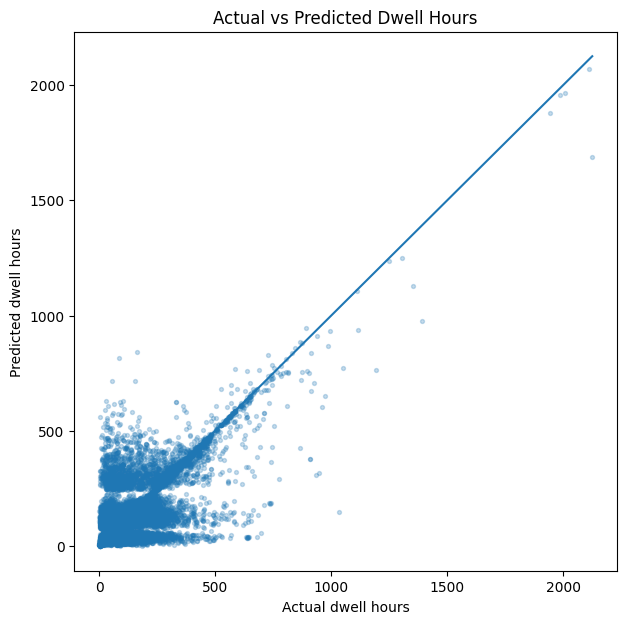

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_hours_test, final_pred, alpha=0.25, s=8)
plt.plot([0, y_hours_test.max()], [0, y_hours_test.max()])
plt.xlabel("Actual dwell hours")
plt.ylabel("Predicted dwell hours")
plt.title("Actual vs Predicted Dwell Hours")
plt.show()

<Figure size 800x500 with 0 Axes>

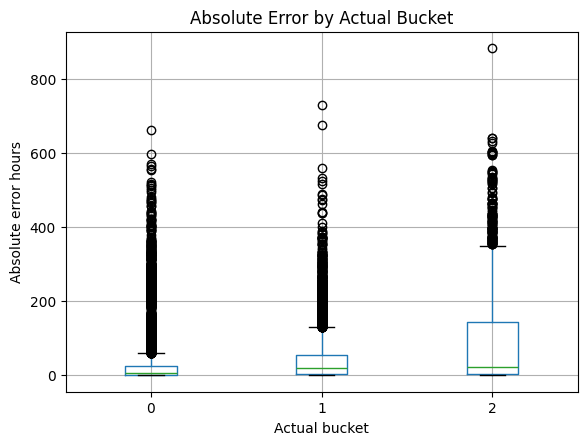

In [13]:
eval_df = pd.DataFrame({
    "actual_dwell_hours": y_hours_test.to_numpy(),
    "predicted_dwell_hours": final_pred,
    "actual_bucket": y_bucket_test.to_numpy(),
    "predicted_bucket": bucket_pred
})

eval_df["error_hours"] = eval_df["predicted_dwell_hours"] - eval_df["actual_dwell_hours"]
eval_df["abs_error_hours"] = eval_df["error_hours"].abs()

plt.figure(figsize=(8, 5))
eval_df.boxplot(column="abs_error_hours", by="actual_bucket")
plt.title("Absolute Error by Actual Bucket")
plt.suptitle("")
plt.xlabel("Actual bucket")
plt.ylabel("Absolute error hours")
plt.show()

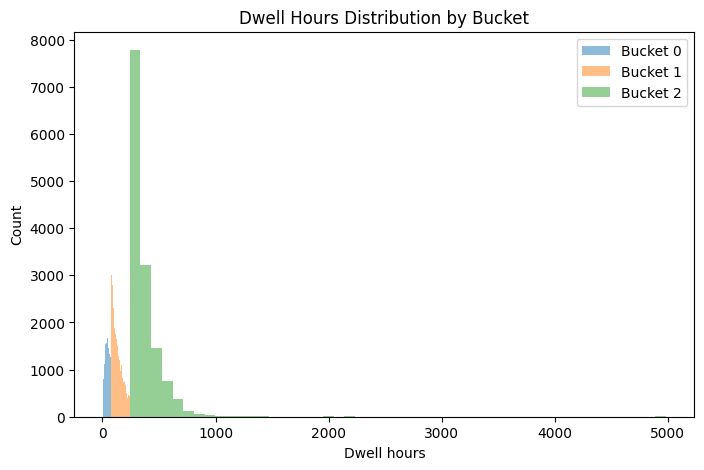

In [14]:
plt.figure(figsize=(8, 5))

for bucket in [0, 1, 2]:
    vals = df.loc[df["dwell_bucket_3"] == bucket, "dwell_hours"]
    plt.hist(vals, bins=50, alpha=0.5, label=f"Bucket {bucket}")

plt.xlabel("Dwell hours")
plt.ylabel("Count")
plt.title("Dwell Hours Distribution by Bucket")
plt.legend()
plt.show()

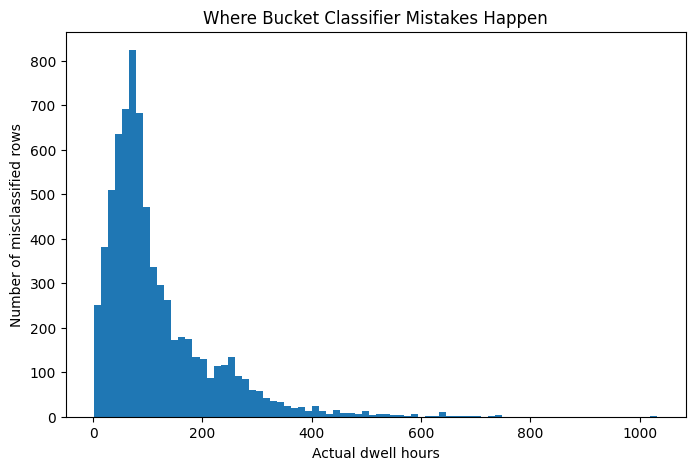

In [15]:
mistakes = eval_df[eval_df["actual_bucket"] != eval_df["predicted_bucket"]].copy()

plt.figure(figsize=(8, 5))
plt.hist(mistakes["actual_dwell_hours"], bins=80)
plt.xlabel("Actual dwell hours")
plt.ylabel("Number of misclassified rows")
plt.title("Where Bucket Classifier Mistakes Happen")
plt.show()

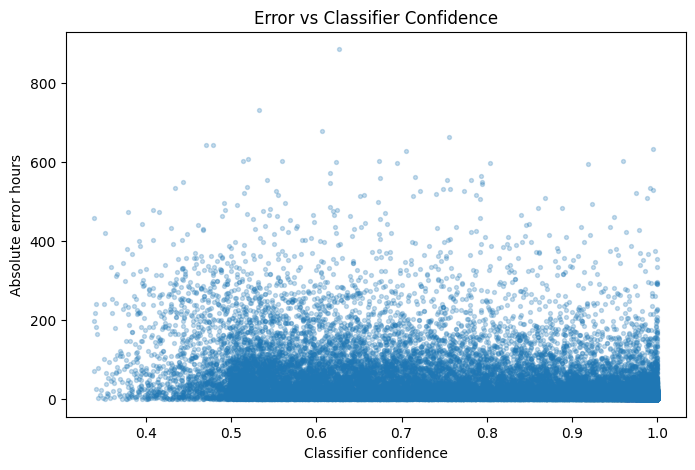

In [16]:
eval_df["classifier_confidence"] = bucket_prob.max(axis=1)

plt.figure(figsize=(8, 5))
plt.scatter(eval_df["classifier_confidence"], eval_df["abs_error_hours"], alpha=0.25, s=8)
plt.xlabel("Classifier confidence")
plt.ylabel("Absolute error hours")
plt.title("Error vs Classifier Confidence")
plt.show()

## Updated model - 4 buckets, prob weighted prediction, reg comparison

Bucket distribution:
dwell_bucket
0    0.288696
1    0.523084
2    0.186152
3    0.002068
Name: proportion, dtype: float64
Dropping object columns: []

Bucket Classifier
-----------------
Accuracy: 0.7302
Balanced accuracy: 0.7350

Confusion matrix:
[[ 6078  1896   403     0]
 [ 2421 11245  1508     4]
 [  373  1191  3819    18]
 [    1     3    10    46]]

Classification report:
              precision    recall  f1-score   support

           0       0.68      0.73      0.70      8377
           1       0.78      0.74      0.76     15178
           2       0.67      0.71      0.69      5401
           3       0.68      0.77      0.72        60

    accuracy                           0.73     29016
   macro avg       0.70      0.74      0.72     29016
weighted avg       0.73      0.73      0.73     29016

Trained bucket 0 regressor on 33,507 rows
Trained bucket 1 regressor on 60,711 rows
Trained bucket 2 regressor on 21,606 rows
Trained bucket 3 regressor on 240 rows

Hard-Routed Two-

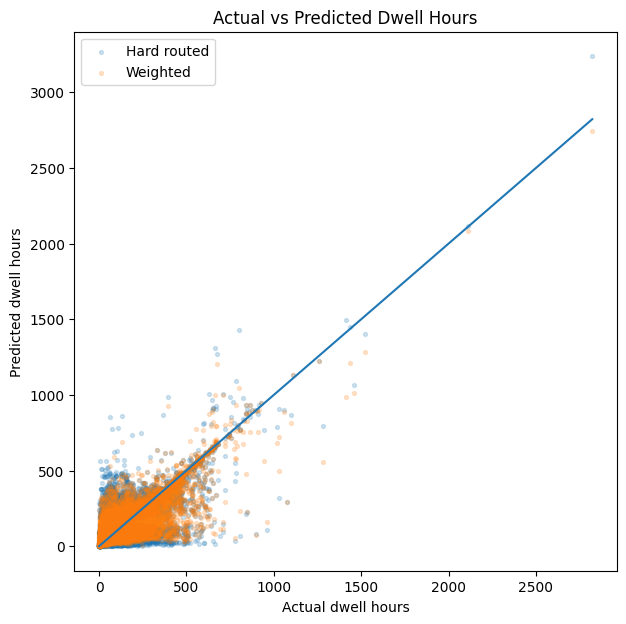

<Figure size 800x500 with 0 Axes>

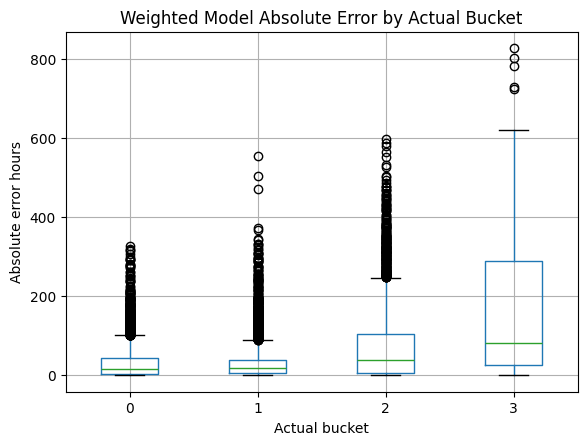

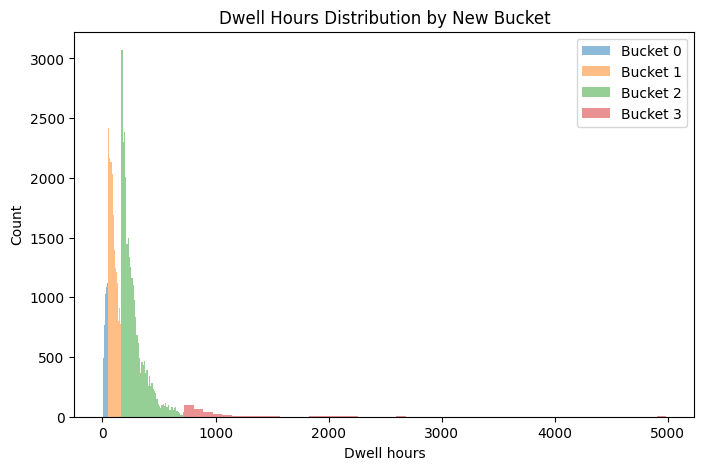

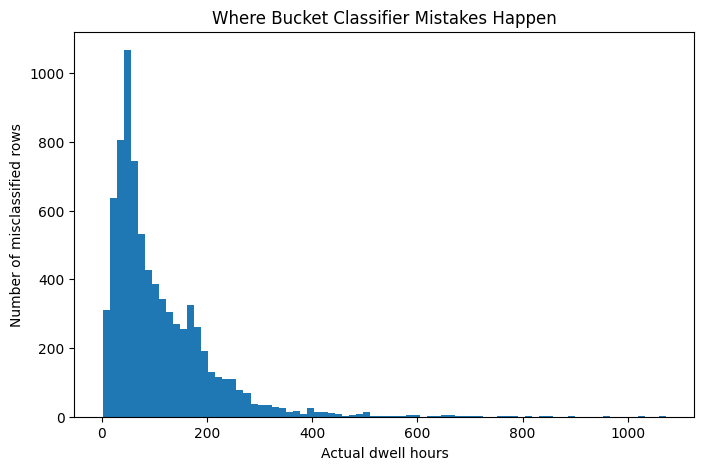

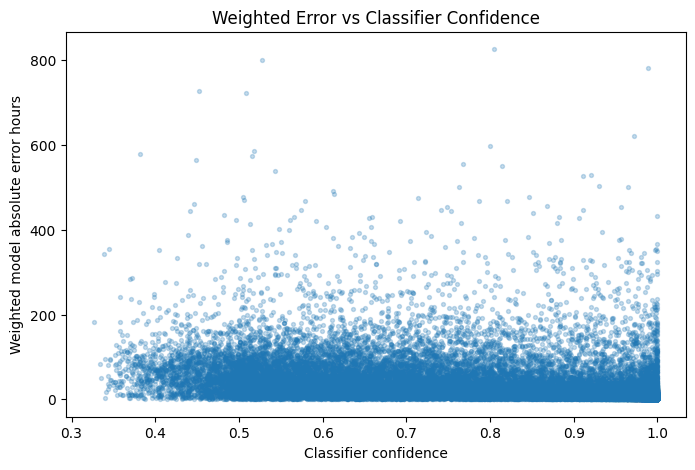

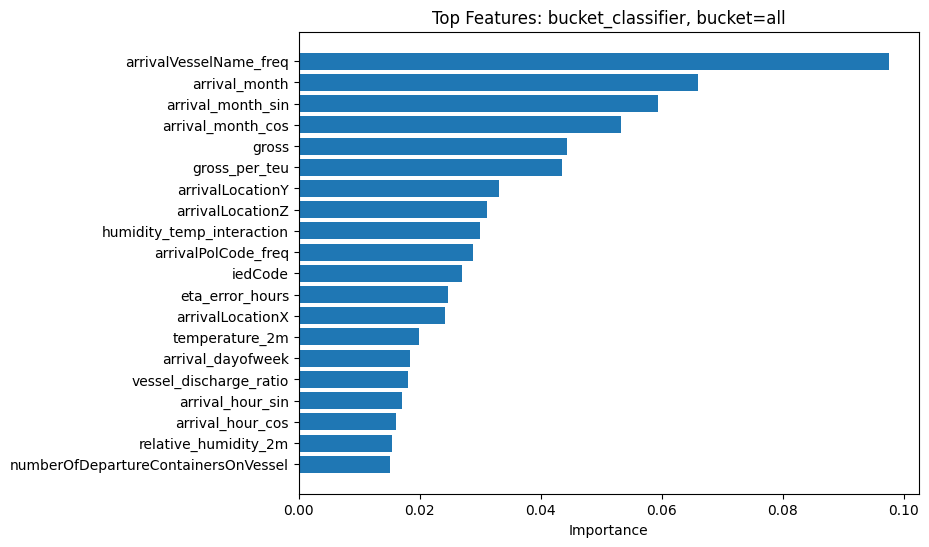

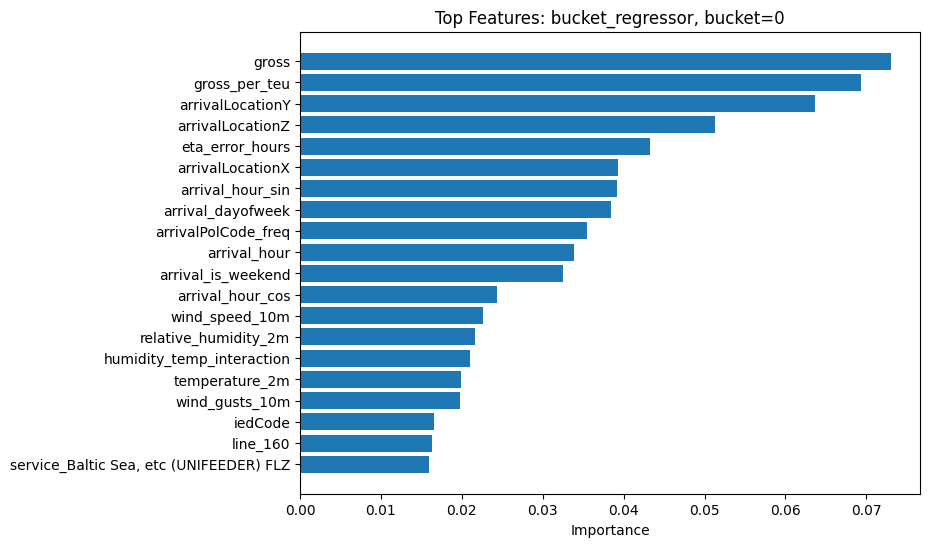

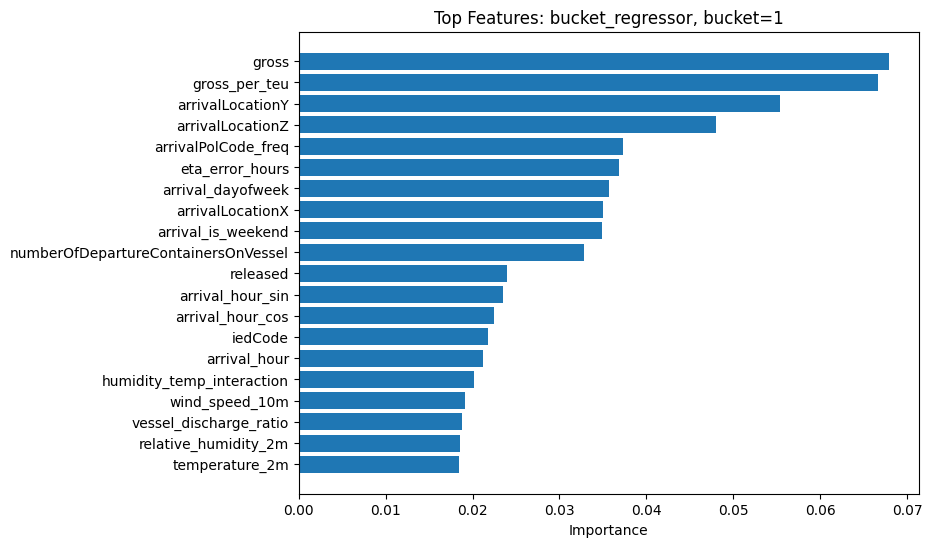

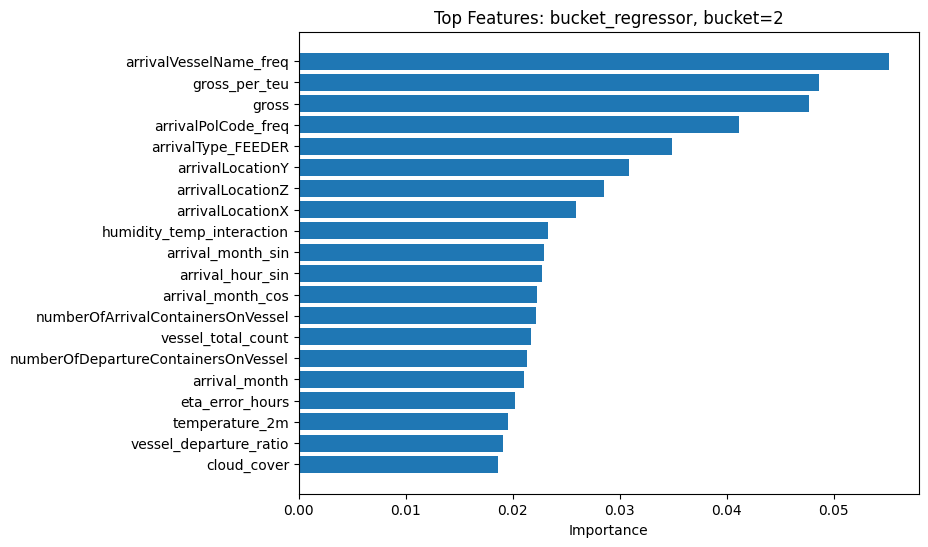

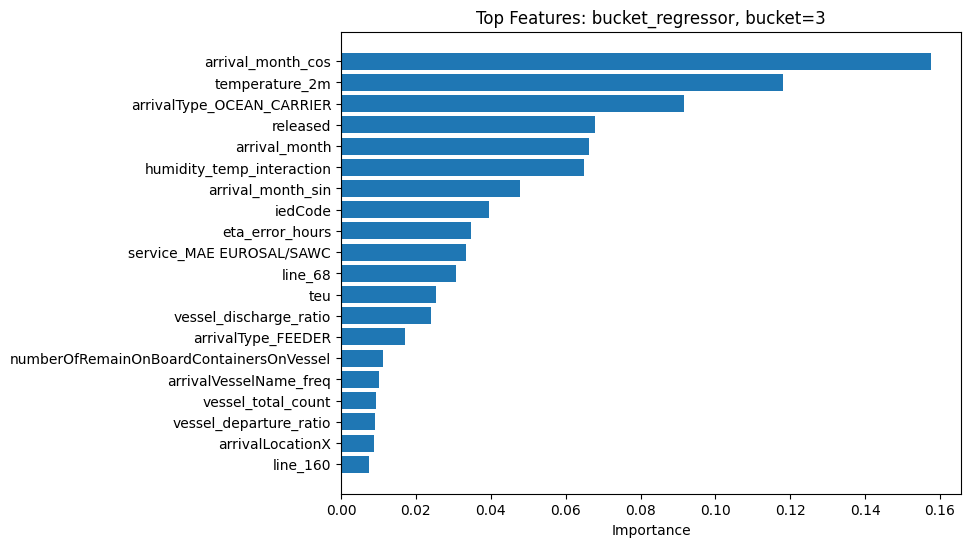

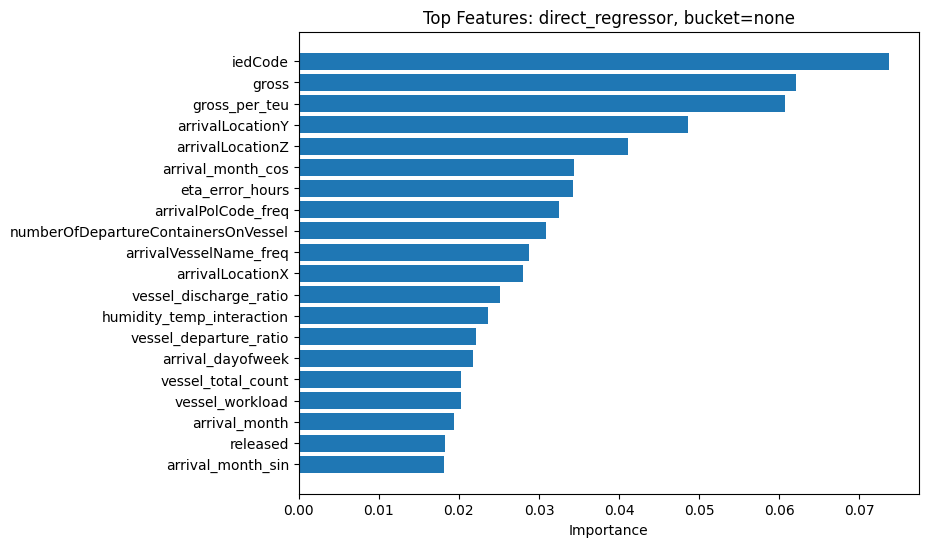

In [2]:
## IMPROVED TWO-STAGE MODEL
## 4 buckets + probability-weighted prediction + direct regression comparison
## Buckets: 0=0-48h, 1=48-168h, 2=168-720h, 3=720h+

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

DATA_PATH = "../data_final/eurogate_postdeparture.csv"
OUT_DIR = "../feature_importance"
TARGET = "dwell_hours"

df = pd.read_csv(DATA_PATH)

# -------------------------
# 1. Create improved buckets
# -------------------------
df["dwell_bucket"] = pd.cut(
    df[TARGET],
    bins=[0, 48, 168, 720, np.inf],
    labels=[0, 1, 2, 3],
    include_lowest=True
).astype(int)

print("Bucket distribution:")
print(df["dwell_bucket"].value_counts(normalize=True).sort_index())

# -------------------------
# 2. Feature engineering
# -------------------------
df["gross_per_teu"] = df["gross"] / df["teu"].replace(0, np.nan)

df["vessel_workload"] = (
    df["numberOfArrivalContainersOnVessel"]
    + df["numberOfDepartureContainersOnVessel"]
)

df["vessel_total_count"] = (
    df["numberOfArrivalContainersOnVessel"]
    + df["numberOfRemainOnBoardContainersOnVessel"]
    + df["numberOfDepartureContainersOnVessel"]
)

df["vessel_discharge_ratio"] = (
    df["numberOfArrivalContainersOnVessel"]
    / df["vessel_total_count"].replace(0, np.nan)
)

df["vessel_departure_ratio"] = (
    df["numberOfDepartureContainersOnVessel"]
    / df["vessel_total_count"].replace(0, np.nan)
)

df["wind_rain_interaction"] = df["wind_speed_10m"] * df["precipitation"]
df["humidity_temp_interaction"] = df["relative_humidity_2m"] * df["temperature_2m"]

# -------------------------
# 3. Prepare X/y
# -------------------------
drop_cols = [
    TARGET,
    "dwell_bucket",
    "dwell_bucket_3",
    "snapshot_time",
    "snapshot_date",
    "snapshot_year",
    "snapshot_hour",
    "snapshot_minute",
    "snapshot_second",
    "arrival_year",
    "departureTime",
    "remaining_dwell_hours",
    "elapsed_dwell_hours",
    "Unnamed: 0",
    "Unnamed: 0.1",
    "Unnamed: 0.2",
    "containerId"
]

df = df.dropna(subset=[TARGET]).copy()

X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y_bucket = df["dwell_bucket"]
y_hours = df[TARGET]

X = X.replace([np.inf, -np.inf], np.nan)

object_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Dropping object columns:", object_cols)
X = X.drop(columns=object_cols)

bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

X = X.fillna(X.median(numeric_only=True))

# -------------------------
# 4. Shared split
# -------------------------
X_train, X_test, y_bucket_train, y_bucket_test, y_hours_train, y_hours_test = train_test_split(
    X,
    y_bucket,
    y_hours,
    test_size=0.20,
    random_state=42,
    stratify=y_bucket
)

# -------------------------
# 5. Bucket classifier
# -------------------------
bucket_model = ExtraTreesClassifier(
    n_estimators=600,
    max_depth=45,
    min_samples_leaf=2,
    min_samples_split=5,
    max_features=0.75,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

bucket_model.fit(X_train, y_bucket_train)

bucket_pred = bucket_model.predict(X_test)
bucket_prob = bucket_model.predict_proba(X_test)

print("\nBucket Classifier")
print("-----------------")
print(f"Accuracy: {accuracy_score(y_bucket_test, bucket_pred):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_bucket_test, bucket_pred):.4f}")
print("\nConfusion matrix:")
print(confusion_matrix(y_bucket_test, bucket_pred))
print("\nClassification report:")
print(classification_report(y_bucket_test, bucket_pred, zero_division=0))

# -------------------------
# 6. Bucket-specific regressors
# -------------------------
regressors = {}
feature_importance_rows = []

feature_importance_rows.append(pd.DataFrame({
    "model": "bucket_classifier",
    "bucket": "all",
    "feature": X.columns,
    "importance": bucket_model.feature_importances_
}))

for bucket in sorted(y_bucket.unique()):
    mask_train = y_bucket_train == bucket

    X_b = X_train.loc[mask_train]
    y_b = y_hours_train.loc[mask_train]

    y_b_log = np.log1p(y_b)

    reg = ExtraTreesRegressor(
        n_estimators=400,
        max_depth=45,
        min_samples_leaf=1,
        min_samples_split=4,
        max_features=0.8,
        bootstrap=False,
        random_state=42,
        n_jobs=-1
    )

    reg.fit(X_b, y_b_log)
    regressors[bucket] = reg

    feature_importance_rows.append(pd.DataFrame({
        "model": "bucket_regressor",
        "bucket": bucket,
        "feature": X.columns,
        "importance": reg.feature_importances_
    }))

    print(f"Trained bucket {bucket} regressor on {len(X_b):,} rows")

# -------------------------
# 7. Hard-routing prediction
# -------------------------
hard_pred = np.zeros(len(X_test))

for bucket in sorted(regressors.keys()):
    mask_pred = bucket_pred == bucket

    if mask_pred.sum() == 0:
        continue

    pred_log = regressors[bucket].predict(X_test.loc[mask_pred])
    hard_pred[mask_pred] = np.maximum(np.expm1(pred_log), 0)

# -------------------------
# 8. Probability-weighted prediction
# -------------------------
bucket_preds_hours = np.zeros((len(X_test), len(regressors)))

for bucket in sorted(regressors.keys()):
    pred_log = regressors[bucket].predict(X_test)
    bucket_preds_hours[:, bucket] = np.maximum(np.expm1(pred_log), 0)

weighted_pred = np.sum(bucket_prob * bucket_preds_hours, axis=1)

# -------------------------
# 9. Direct regression baseline
# -------------------------
direct_model = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=45,
    min_samples_leaf=1,
    min_samples_split=4,
    max_features=0.8,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

direct_model.fit(X_train, np.log1p(y_hours_train))

direct_pred = np.maximum(
    np.expm1(direct_model.predict(X_test)),
    0
)

feature_importance_rows.append(pd.DataFrame({
    "model": "direct_regressor",
    "bucket": "none",
    "feature": X.columns,
    "importance": direct_model.feature_importances_
}))

# -------------------------
# 10. Evaluation helper
# -------------------------
def evaluate_predictions(name, y_true, pred):
    abs_err = np.abs(y_true.to_numpy() - pred)

    print(f"\n{name}")
    print("-" * len(name))
    print(f"MAE: {mean_absolute_error(y_true, pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, pred)):.2f}")
    print(f"R²: {r2_score(y_true, pred):.4f}")
    print(f"Within 6h: {(abs_err <= 6).mean():.2%}")
    print(f"Within 12h: {(abs_err <= 12).mean():.2%}")
    print(f"Within 24h: {(abs_err <= 24).mean():.2%}")

evaluate_predictions("Hard-Routed Two-Stage Model", y_hours_test, hard_pred)
evaluate_predictions("Probability-Weighted Two-Stage Model", y_hours_test, weighted_pred)
evaluate_predictions("Direct Extra Trees Regression", y_hours_test, direct_pred)

# -------------------------
# 11. Bucket-level diagnostics
# -------------------------
eval_df = pd.DataFrame({
    "actual_dwell_hours": y_hours_test.to_numpy(),
    "hard_predicted_dwell_hours": hard_pred,
    "weighted_predicted_dwell_hours": weighted_pred,
    "direct_predicted_dwell_hours": direct_pred,
    "actual_bucket": y_bucket_test.to_numpy(),
    "predicted_bucket": bucket_pred,
    "classifier_confidence": bucket_prob.max(axis=1)
})

for pred_col in [
    "hard_predicted_dwell_hours",
    "weighted_predicted_dwell_hours",
    "direct_predicted_dwell_hours"
]:
    eval_df[f"{pred_col}_abs_error"] = (
        eval_df[pred_col] - eval_df["actual_dwell_hours"]
    ).abs()

print("\nWithin 24h by ACTUAL bucket:")
for bucket in sorted(y_bucket.unique()):
    mask = eval_df["actual_bucket"] == bucket
    print(f"\nActual bucket {bucket}, n={mask.sum():,}")

    for pred_col in [
        "hard_predicted_dwell_hours",
        "weighted_predicted_dwell_hours",
        "direct_predicted_dwell_hours"
    ]:
        err_col = f"{pred_col}_abs_error"
        print(
            f"{pred_col}: "
            f"Within 24h = {(eval_df.loc[mask, err_col] <= 24).mean():.2%}, "
            f"MAE = {eval_df.loc[mask, err_col].mean():.2f}"
        )

# -------------------------
# 12. Save predictions and feature importance
# -------------------------
for i, bucket in enumerate(sorted(regressors.keys())):
    eval_df[f"prob_bucket_{bucket}"] = bucket_prob[:, i]

eval_df.to_csv(
    f"{OUT_DIR}/improved_two_stage_predictions.csv",
    index=False
)

feature_importance = (
    pd.concat(feature_importance_rows, ignore_index=True)
    .sort_values(["model", "bucket", "importance"], ascending=[True, True, False])
)

feature_importance.to_csv(
    f"{OUT_DIR}/improved_two_stage_ranked_feature_importance.csv",
    index=False
)

joblib.dump(bucket_model, f"{OUT_DIR}/improved_bucket_classifier.joblib")
joblib.dump(regressors, f"{OUT_DIR}/improved_bucket_regressors.joblib")
joblib.dump(direct_model, f"{OUT_DIR}/direct_extra_trees_regressor.joblib")

print("\nSaved:")
print(f"{OUT_DIR}/improved_two_stage_predictions.csv")
print(f"{OUT_DIR}/improved_two_stage_ranked_feature_importance.csv")
print(f"{OUT_DIR}/improved_bucket_classifier.joblib")
print(f"{OUT_DIR}/improved_bucket_regressors.joblib")
print(f"{OUT_DIR}/direct_extra_trees_regressor.joblib")

# -------------------------
# 13. Visualization
# -------------------------

# Actual vs predicted: compare approaches
plt.figure(figsize=(7, 7))
plt.scatter(y_hours_test, hard_pred, alpha=0.2, s=8, label="Hard routed")
plt.scatter(y_hours_test, weighted_pred, alpha=0.2, s=8, label="Weighted")
plt.plot([0, y_hours_test.max()], [0, y_hours_test.max()])
plt.xlabel("Actual dwell hours")
plt.ylabel("Predicted dwell hours")
plt.title("Actual vs Predicted Dwell Hours")
plt.legend()
plt.show()

# Absolute error by bucket
plt.figure(figsize=(8, 5))
eval_df.boxplot(
    column="weighted_predicted_dwell_hours_abs_error",
    by="actual_bucket"
)
plt.title("Weighted Model Absolute Error by Actual Bucket")
plt.suptitle("")
plt.xlabel("Actual bucket")
plt.ylabel("Absolute error hours")
plt.show()

# Dwell distribution by bucket
plt.figure(figsize=(8, 5))
for bucket in sorted(df["dwell_bucket"].unique()):
    vals = df.loc[df["dwell_bucket"] == bucket, TARGET]
    plt.hist(vals, bins=50, alpha=0.5, label=f"Bucket {bucket}")
plt.xlabel("Dwell hours")
plt.ylabel("Count")
plt.title("Dwell Hours Distribution by New Bucket")
plt.legend()
plt.show()

# Classifier mistakes
mistakes = eval_df[eval_df["actual_bucket"] != eval_df["predicted_bucket"]]

plt.figure(figsize=(8, 5))
plt.hist(mistakes["actual_dwell_hours"], bins=80)
plt.xlabel("Actual dwell hours")
plt.ylabel("Number of misclassified rows")
plt.title("Where Bucket Classifier Mistakes Happen")
plt.show()

# Error vs classifier confidence
plt.figure(figsize=(8, 5))
plt.scatter(
    eval_df["classifier_confidence"],
    eval_df["weighted_predicted_dwell_hours_abs_error"],
    alpha=0.25,
    s=8
)
plt.xlabel("Classifier confidence")
plt.ylabel("Weighted model absolute error hours")
plt.title("Weighted Error vs Classifier Confidence")
plt.show()

# Feature importance plots
importance = pd.read_csv(f"{OUT_DIR}/improved_two_stage_ranked_feature_importance.csv")

for model_name in importance["model"].unique():
    model_subset = importance[importance["model"] == model_name]

    for bucket in model_subset["bucket"].unique():
        subset = model_subset[model_subset["bucket"] == bucket].head(20)

        plt.figure(figsize=(8, 6))
        plt.barh(subset["feature"], subset["importance"])
        plt.title(f"Top Features: {model_name}, bucket={bucket}")
        plt.xlabel("Importance")
        plt.gca().invert_yaxis()
        plt.show()